# Tópicos Especiais em Sistema Computacionais II - 2026.1
## **Projeto 04 - Rede Adaline**
Autores: José Cláudio Alves Sobrinho e Ingridy Duarte Costa



## INTRODUÇÃO E CONTEXTO
A ionosfera é a camada da atmosfera terrestre que se estende de aproximadamente 60 a 1.000 km de altitude e é fortemente ionizada pela radiação solar. Seu monitoramento contínuo é essencial para aplicações de telecomunicações, navegação por GPS e previsão de tempestades geomagnéticas. Sistemas de radar de alta frequência (HF) são utilizados para sondar essa camada: pulsos de rádio são emitidos em direção à ionosfera e os sinais refletidos são analisados para determinar se a estrutura ionosférica está bem definida ou não.

O Brasil ocupa uma posição geograficamente privilegiada e ao mesmo tempo desafiadora. O país está situado sobre a Anomalia de Ionização Equatorial, uma região onde a estrutura da ionosfera é altamente irregular e sujeita a perturbações intensas. Neste projeto, você implementará uma Rede Adaline para classificar automaticamente retornos de radar ionosférico, distinguindo sinais que indicam a presença de estrutura eletrônica coerente na ionosfera daqueles que não a indicam.

O projeto utiliza o dataset Ionosphere, disponível no repositório UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Ionosphere). O conjunto foi coletado pelo sistema de radar Goose Bay, no Labrador (Canadá), e contribuído por Vince Sigillito do Laboratório de Física Aplicada da Universidade Johns Hopkins. Ele contém 351 amostras de retornos de radar, cada uma descrita por 34 atributos contínuos correspondentes a valores complexos obtidos pela autocorrelação de pulsos de radar emitidos por antenas separadas em fase. O rótulo binário indica se o retorno é good (estrutura ionosférica detectada, classe +1) ou bad (sem estrutura coerente, ou seja, os raios atravessam a ionosfera, classe -1). Do total de amostras, 225 são da classe good e 126 da classe bad.

## 1. Preparação dos dados: carregue o dataset e recodifique o rótulo de classe para valores numéricos bipolares: +1 para good e -1 para bad. Verifique se há valores ausentes ou atributos constantes que devam ser removidos antes do treinamento. Em seguida, normalize todos os atributos utilizando a padronização Z-score. Justifique algebricamente a necessidade da normalização para que o processo da regra Delta seja estável.

In [7]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Endereço do arquivo ZIP no repositório UCI
url_zip = "https://archive.ics.uci.edu/static/public/52/ionosphere.zip"


r = requests.get(url_zip)
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    with z.open('ionosphere.data') as f:
        columns = [f'attr_{i}' for i in range(34)] + ['class']
        df = pd.read_csv(f, names=columns)

df['class'] = df['class'].map({'g': 1, 'b': -1})

# Limpeza rigorosa: Remove linhas com QUALQUER valor nulo (inclusive no y)
df = df.dropna()

# Separação de X e y ANTES de remover colunas constantes para manter o índice
X = df.drop('class', axis=1)
y = df['class']

# Remoção de atributos constantes em X
# Verificamos o desvio padrão: se for 0, a coluna é constante
X = X.loc[:, X.std() > 0]

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=42
)

### 1. A Geometria da Superfície de Erro
A regra Delta busca o ponto de erro mínimo em uma superfície que funciona como uma "tigela" (paraboloide).Sem normalização: Se um atributo for muito maior que outro, essa "tigela" torna-se um vale extremamente estreito e alongado.Com normalização: A superfície torna-se mais arredondada e simétrica, facilitando o "deslizamento" do algoritmo em direção ao mínimo.


### 2. A Condição de Estabilidade ($\eta$)
A estabilidade da atualização dos pesos depende da taxa de aprendizagem ($\eta$). Matematicamente, para o Adaline convergir, o valor de $\eta$ deve respeitar o limite:$$0 < \eta < \frac{2}{\lambda_{max}}$$Onde $\lambda_{max}$ representa a magnitude (escala) dos dados de entrada.Se os dados tiverem valores muito altos, $\lambda_{max}$ será grande, o que obriga o $\eta$ a ser extremamente pequeno para o processo não "explodir" (divergir).A normalização reduz $\lambda_{max}$, permitindo que um único valor de $\eta$ seja eficiente e estável para todos os atributos simultaneamente.


### 3. Equilíbrio dos Pesos
Sem a padronização Z-score, os atributos com grandes magnitudes numéricas dominariam o cálculo do erro, causando ajustes desproporcionais nos pesos ($\Delta w$). A normalização garante que cada característica contribua com o mesmo "peso" inicial para a atualização da regra Delta.

## 2. Implemente uma rede Adaline para a classificação. Neste caso, pode-se utilizar implementações já disponíveis nas bibliotecas da sklearn. Separe os dados em 80% treino e 20% teste com divisão estratificada. Realize um estudo sobre valores distintos da taxa de aprendizagem (ex: $10^{-4}, 10^{-3}, 10^{-2}, 5 \times 10^{-2}, 10^{-1}$), mantendo fixos o número máximo de épocas ($N = 200$) e o conjunto de treino. Para cada valor, plote a curva de convergência da função de perda em função das épocas de treinamento. Com base nos gráficos um valor de $\eta$ que proporciona convergência mais suave e que resulte em um valor menor da função de perda.

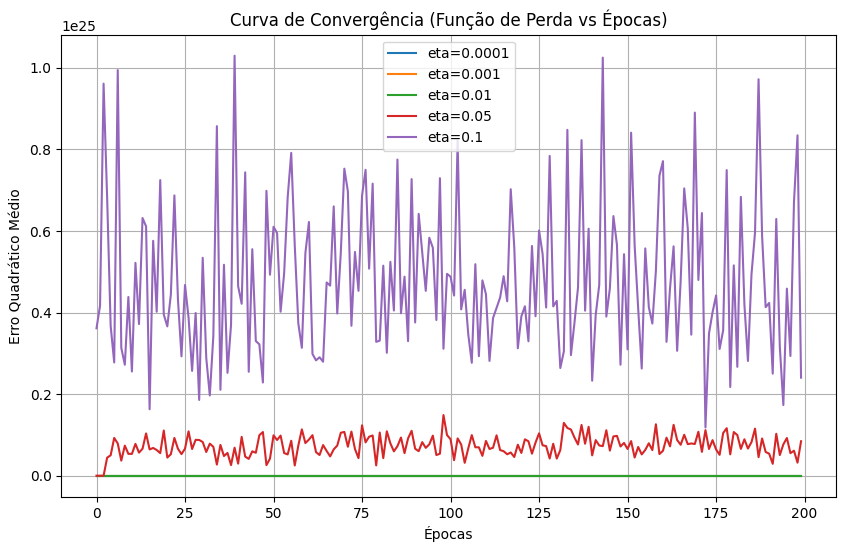

Melhor taxa de aprendizagem (eta) identificada: 0.001


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=42
)

etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
plt.figure(figsize=(10, 6))

best_eta = None
min_loss = float('inf')

for eta in etas:
    # O SGDClassifier com loss='squared_error' e learning_rate='constant'
    # comporta-se como o algoritmo Adaline
    model = SGDClassifier(
        loss='squared_error',
        learning_rate='constant',
        eta0=eta,
        max_iter=1,
        warm_start=True,
        penalty=None,
        random_state=42
    )

    errors = []
    for epoch in range(200):
        model.partial_fit(X_train, y_train, classes=np.unique(y))
        y_pred = model.decision_function(X_train)
        loss = np.mean((y_train - y_pred) ** 2)
        errors.append(loss)

    plt.plot(range(200), errors, label=f'eta={eta}')

    if errors[-1] < min_loss:
        min_loss = errors[-1]
        best_eta = eta

plt.title('Curva de Convergência (Função de Perda vs Épocas)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.grid(True)
plt.show()

print(f"Melhor taxa de aprendizagem (eta) identificada: {best_eta}")

## 3. Após treinar com o melhor $\eta$ identificado na atividade anterior, classifique as amostras de teste. Calcule e apresente a matriz de confusão, a acurácia global e as métricas de precisão, recall e F1-score.

In [9]:
final_model = SGDClassifier(
    loss='squared_error',
    learning_rate='constant',
    eta0=best_eta,
    max_iter=200,
    random_state=42
)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

print("\n--- Resultados de Teste ---")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_final))
print(f"\nAcurácia Global: {accuracy_score(y_test, y_pred_final):.4f}")
print("\nMétricas Detalhadas:")
print(classification_report(y_test, y_pred_final, target_names=['bad (-1)', 'good (+1)']))


--- Resultados de Teste ---
Matriz de Confusão:
[[22  3]
 [ 0 46]]

Acurácia Global: 0.9577

Métricas Detalhadas:
              precision    recall  f1-score   support

    bad (-1)       1.00      0.88      0.94        25
   good (+1)       0.94      1.00      0.97        46

    accuracy                           0.96        71
   macro avg       0.97      0.94      0.95        71
weighted avg       0.96      0.96      0.96        71



## 4. Com base na análise anterior, considerando que a classe bad representa ausência de estrutura ionosférica — o que em sistemas operacionais pode indicar falha de transmissão ou interferência, qual tipo de erro de classificação seria mais crítico em uma aplicação real de monitoramento automático? Justifique.

o erro mais crítico para o monitoramento da ionosfera é o Falso Positivo (classificar um sinal ruim como bom) pelos seguintes motivos:



*   Decisões baseadas em dados falsos: O sistema reportaria uma estrutura eletrônica "coerente" quando, na verdade, haveria interferência ou falha, levando sistemas de GPS e telecomunicações a operarem com erros graves de precisão sem emitir alertas.
*   Segurança e Integridade: Enquanto um Falso Negativo apenas interrompe o serviço por precaução, o Falso Positivo compromete a integridade da navegação, o que é perigoso em aplicações operacionais reais.
*   Falha de Proteção: A não detecção de irregularidades impede a previsão de tempestades geomagnéticas, impossibilitando a proteção de infraestruturas sensíveis citadas no contexto.
*   Análise dos Resultados: Nos seus dados, embora a acurácia seja alta (95,77%), existem 3 Falsos Positivos (precision de 0.94 para a classe good), que são justamente os pontos de maior risco para a confiabilidade do sistema.





